In [10]:
#run under conda deepchem enviroment
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold

import mols2grid

import optuna

import pickle
import joblib

import gc

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

#from sklearn.pipeline import Pipeline

#from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

#from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance

In [11]:
df_large_cov = pd.read_csv('../QM_calculation/qm_augmented_classification_dataset.csv')
df_large_cov

,stereo_smiles,HOMO_eV,LUMO_eV,gap_eV,cov_crbn_label,electrophilicity_index_eV
0,O=C1CNC(=O)N1,-11.590900,-7.286400,4.304500,0,20.696507
1,CC(=O)NC(N)=O,-11.141100,-7.024100,4.117000,0,20.037314
2,CC1CC(=O)NC(=O)C1,-11.444642,-7.606959,3.837683,0,23.644704
3,O=C1CC[C@H](NC(=O)c2cnc[nH]2)C(=O)N1,-10.727853,-8.037834,2.690019,0,32.727554
4,O=C1CC[C@@H](NC(=O)c2ccc3ccncc3c2)C(=O)N1,-10.240521,-8.134725,2.105796,0,40.085759
...,...,...,...,...,...,...
15996,O=C1CC[C@@H](N2Cc3cc(-c4nc5ccccn5c4Cl)ccc3C2=O...,-10.482660,-7.835794,2.646866,0,31.694624
15997,O=C1CC[C@H](N2Cc3c(cccc3-c3ccc(C4CC4)cc3Cl)C2=...,-10.635180,-7.839121,2.796059,0,30.516145
15998,O=C1CC[C@@H](N2Cc3c(cccc3-c3ccc(C4CC4)cc3Cl)C2...,-10.635593,-7.839459,2.796134,0,30.517817
15999,O=C1CC[C@H](NC(=O)c2ccc(NCCN3CCOCC3)c(Cl)c2)C(...,-10.054784,-7.971111,2.083673,0,38.985592


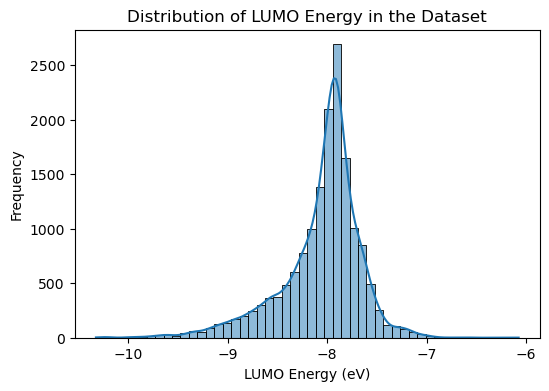

In [12]:
#distribution plot of LUMO energy
plt.figure(figsize=(6,4))
sns.histplot(df_large_cov['LUMO_eV'], bins=50, kde=True)
plt.xlabel('LUMO Energy (eV)')
plt.ylabel('Frequency')
plt.title('Distribution of LUMO Energy in the Dataset')
plt.show()

In [13]:
df_large_cov[['stereo_smiles', 'LUMO_eV']].to_csv('crbn_lumo_dataset_for_regression.csv', index=False)

In [14]:
df_large_cov = pd.read_csv('crbn_lumo_dataset_for_regression.csv')
df_large_cov = df_large_cov.astype({'stereo_smiles': 'string', 'LUMO_eV': 'float'})
df_large_cov['Structure'] = df_large_cov['stereo_smiles'].apply(lambda x: Chem.MolFromSmiles(x))
mols2grid.display(df_large_cov['Structure'].tolist(), size=(200,200), colormap='RdYlBu', show_legend=True)

In [6]:
# Analyze bit usage for different fingerprint sizes and radii (do not ignore stereochemistry)
for b in [1024, 2048, 4096, 8192, 16384]:
    for r in range(2,4):
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=r, fpSize=b, includeChirality=True)
        
        # Track bit usage counts
        bit_usage_counts = {}
        for x in df_large_cov['Structure']:
            mfp = fpg.GetFingerprint(x)
            for bit_idx in mfp.GetOnBits():
                bit_usage_counts[bit_idx] = bit_usage_counts.get(bit_idx, 0) + 1
        
        # Calculate statistics
        num_bits_used = len(bit_usage_counts)
        utilization = (num_bits_used / b) * 100
        usage_values = list(bit_usage_counts.values())
        
        print(f"Size {b}, Radius {r}: {num_bits_used} active bits ({utilization:.1f}% utilization)")
        print(f"  Bits used 1 time: {sum(1 for v in usage_values if v == 1)}")
        print(f"  Bits used 2-5 times: {sum(1 for v in usage_values if 2 <= v <= 5)}")
        print(f"  Bits used 6-10 times: {sum(1 for v in usage_values if 6 <= v <= 10)}")
        print(f"  Bits used >10 times: {sum(1 for v in usage_values if v > 10)}")
        print(f"  Average fragments per bit: {np.mean(usage_values):.1f}")
        print(f"  Max fragments for single bit: {max(usage_values)}")
        print()

Size 1024, Radius 2: 1024 active bits (100.0% utilization)
  Bits used 1 time: 0
  Bits used 2-5 times: 0
  Bits used 6-10 times: 0
  Bits used >10 times: 1024
  Average fragments per bit: 837.4
  Max fragments for single bit: 16001

Size 1024, Radius 3: 1024 active bits (100.0% utilization)
  Bits used 1 time: 0
  Bits used 2-5 times: 0
  Bits used 6-10 times: 0
  Bits used >10 times: 1024
  Average fragments per bit: 1128.9
  Max fragments for single bit: 16001

Size 2048, Radius 2: 2047 active bits (100.0% utilization)
  Bits used 1 time: 0
  Bits used 2-5 times: 10
  Bits used 6-10 times: 24
  Bits used >10 times: 2013
  Average fragments per bit: 423.7
  Max fragments for single bit: 16001

Size 2048, Radius 3: 2048 active bits (100.0% utilization)
  Bits used 1 time: 0
  Bits used 2-5 times: 0
  Bits used 6-10 times: 0
  Bits used >10 times: 2048
  Average fragments per bit: 573.8
  Max fragments for single bit: 16001

Size 4096, Radius 2: 4048 active bits (98.8% utilization)
  B

In [15]:
# Re-create fingerprint generator with bit info tracking
fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=8192, includeChirality=True)
ao = rdFingerprintGenerator.AdditionalOutput()
ao.AllocateBitInfoMap()

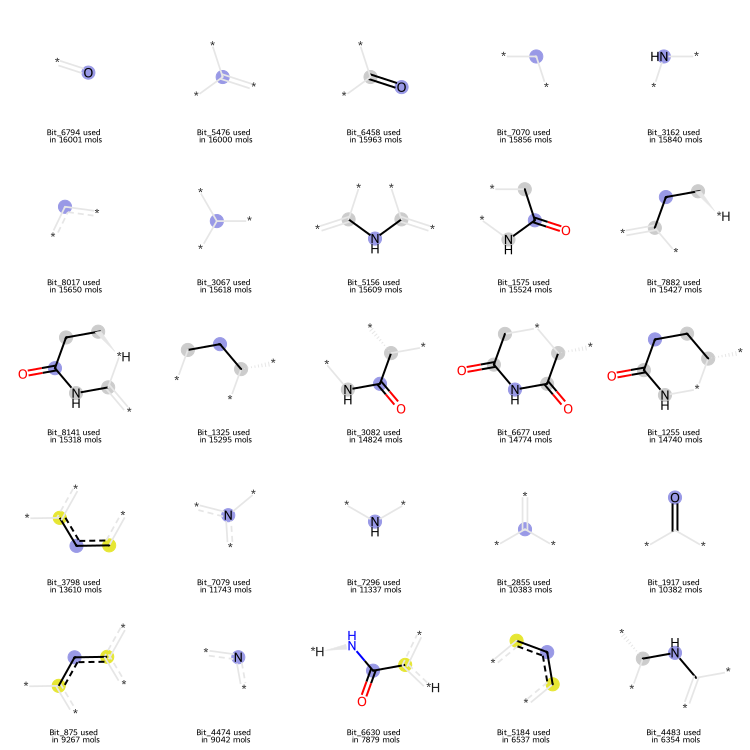

In [16]:
# Generate fingerprints to populate bit info map
bit_usage_counts = {}
all_with_label = []
for x in df_large_cov['Structure']:
    current_mfp = fpg.GetFingerprint(x, additionalOutput=ao)
    for bit_idx in current_mfp.GetOnBits():
        bit_usage_counts[bit_idx] = bit_usage_counts.get(bit_idx, 0) + 1
        fragment_tuple = (x, bit_idx, ao.GetBitInfoMap())
        all_with_label.append(fragment_tuple)

# draw most 25 unique bits sorted by usage
unique_bits = []
for mol, bit_idx, bit_info_map in all_with_label:
    if bit_idx not in [t[1] for t in unique_bits]:
        unique_bits.append((mol, bit_idx, bit_info_map))
unique_bits.sort(key=lambda x: bit_usage_counts[x[1]], reverse=True)
Draw.DrawMorganBits(unique_bits[:25], molsPerRow=5, legends=[f'Bit_{str(t[1])} used \n in {str(bit_usage_counts[t[1]])} mols' for t in unique_bits[:25]], subImgSize=(150,150))

In [8]:
# Create dataframe with fingerprint bits as columns
list_mfp = [fpg.GetFingerprint(x) for x in df_large_cov['Structure']]
bit_name = [f'Bit_{i}' for i in range(8192)]
bits = [list(l) for l in list_mfp]
df_mfp = pd.DataFrame(bits, columns=bit_name)
df_merged = pd.concat([df_large_cov, df_mfp], axis=1, join='inner')
df_data = df_merged.drop(columns=['Structure'])
df_data.to_csv('crbn_lumo_dataset_with_fingerprints.csv', index=False)

In [2]:
df_data = pd.read_csv('crbn_lumo_dataset_with_fingerprints.csv')
X = df_data.drop(columns=['stereo_smiles', 'LUMO_eV'])
y = df_data['LUMO_eV']

# Scaffold split utilities (Bemis–Murcko)
def compute_scaffold(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

def scaffold_split_indices(smiles_list, test_ratio=0.2, seed=42):
    """Return train/test indices using scaffold split for better generalization."""
    rng = np.random.default_rng(seed)
    scaffold_to_indices = {}
    for i, smi in enumerate(smiles_list):
        scaf = compute_scaffold(smi)
        scaffold_to_indices.setdefault(scaf, []).append(i)
    # Shuffle scaffolds deterministically
    scaffolds = list(scaffold_to_indices.keys())
    rng.shuffle(scaffolds)
    n = len(smiles_list)
    target_test = int(round(test_ratio * n))
    test_indices, train_indices = [], []
    covered = set()
    for scaf in scaffolds:
        bucket = scaffold_to_indices[scaf]
        if len(test_indices) < target_test:
            test_indices.extend(bucket)
        else:
            train_indices.extend(bucket)
        covered.update(bucket)
    assert len(covered) == n, "Scaffold split did not cover all samples"
    return np.array(train_indices), np.array(test_indices)

train_idx, test_idx = scaffold_split_indices(df_data['stereo_smiles'].tolist(), test_ratio=0.2, seed=42)
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
len(X_train), len(X_test), len(y_train), len(y_test)

# save train and test smiles and labels for later DL use
train_data = pd.DataFrame({
    'stereo_smiles': df_data['stereo_smiles'].iloc[train_idx],
    'LUMO_eV': y_train
})
test_data = pd.DataFrame({
    'stereo_smiles': df_data['stereo_smiles'].iloc[test_idx],
    'LUMO_eV': y_test
})
train_data.to_csv('train_data.csv', index=False)
test_data.to_csv('test_data.csv', index=False)

In [3]:
#further tuning hyperparameters of SVM using Optuna based on Bayesian optimization
def objective(trial):
    # Simplified Parameter Pool
    param = {
        'C': trial.suggest_float('C', 1e-2, 1e2, log=True),
        'epsilon': trial.suggest_float('epsilon', 0.01, 0.5, log=True),
        'kernel': trial.suggest_categorical('kernel', ['rbf', 'linear']),
    }

    # Conditional logic for RBF-specific parameters
    if param['kernel'] == 'rbf':
        # Suggest 'scale' as a strong baseline or a float range
        param['gamma'] = trial.suggest_float('gamma', 1e-4, 1e-1, log=True)
        
    model = SVR(**param)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
print(f"Best Params: {study.best_params}")

# Train and evaluate best model
best_svm_optuna = SVR(**study.best_params)
best_svm_optuna.fit(X_train, y_train)
y_pred_optuna = best_svm_optuna.predict(X_test)
r2_optuna = r2_score(y_test, y_pred_optuna)
print(f"Optuna-tuned SVM - Test R2: {r2_optuna:.4f}")
joblib.dump(best_svm_optuna, 'best_svr_model_optuna.pkl')

[I 2026-03-02 21:09:28,867] A new study created in memory with name: no-name-bc87a874-2d44-404e-8b9d-7951f75e7a18
[I 2026-03-02 21:25:53,449] Trial 0 finished with value: -0.12509084964516337 and parameters: {'C': 0.017225634660717824, 'epsilon': 0.21721531748448208, 'kernel': 'rbf', 'gamma': 0.0012352743458984104}. Best is trial 0 with value: -0.12509084964516337.
[I 2026-03-03 01:55:32,953] Trial 1 finished with value: -0.0630717207394259 and parameters: {'C': 73.48454001570818, 'epsilon': 0.010166741855789101, 'kernel': 'rbf', 'gamma': 0.007370844565750076}. Best is trial 1 with value: -0.0630717207394259.
[I 2026-03-03 02:20:08,670] Trial 2 finished with value: -0.06878729992798464 and parameters: {'C': 0.17001617820748502, 'epsilon': 0.07496611170715484, 'kernel': 'linear'}. Best is trial 1 with value: -0.0630717207394259.
[I 2026-03-03 02:45:17,679] Trial 3 finished with value: -0.05355412226028444 and parameters: {'C': 53.08382187510271, 'epsilon': 0.054848640277525916, 'kernel'

Best Params: {'C': 0.5643909455178833, 'epsilon': 0.02087715716348664, 'kernel': 'rbf', 'gamma': 0.011735996279118656}
Optuna-tuned SVM - Test R2: 0.7269


['best_svr_model_optuna.pkl']

In [4]:
#reload the model
loaded_svm_optuna = joblib.load('best_svr_model_optuna.pkl')
y_pred_train = loaded_svm_optuna.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
print(f"Optuna-tuned SVM - Train R2: {r2_train:.4f} | MSE: {mse_train:.4f} | MAE: {mae_train:.4f}")
y_pred_test = loaded_svm_optuna.predict(X_test)
r2_test = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
print(f"Optuna-tuned SVM - Test R2: {r2_test:.4f} | MSE: {mse_test:.4f} | MAE: {mae_test:.4f}")

Optuna-tuned SVM - Train R2: 0.8838 | MSE: 0.0197 | MAE: 0.0732
Optuna-tuned SVM - Test R2: 0.7269 | MSE: 0.0408 | MAE: 0.1409


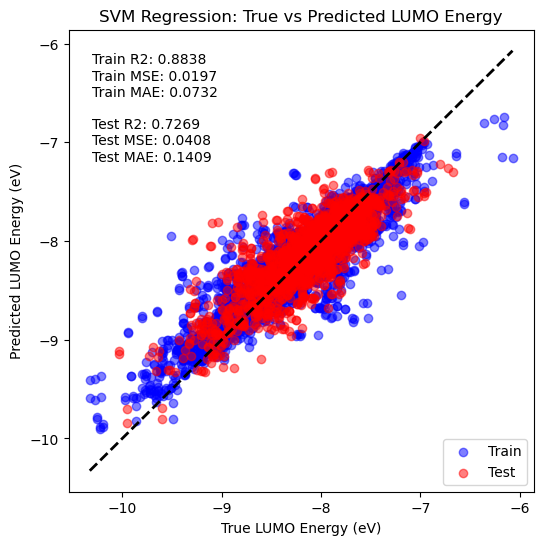

In [5]:
#regression plot including training and test data and label each performance metrics in the plot
plt.figure(figsize=(6,6))
plt.scatter(y_train, y_pred_train, color='blue', alpha=0.5, label='Train')
plt.scatter(y_test, y_pred_test, color='red', alpha=0.5, label='Test')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('True LUMO Energy (eV)')
plt.ylabel('Predicted LUMO Energy (eV)')
plt.title(f'SVM Regression: True vs Predicted LUMO Energy')
plt.text(0.05, 0.95, f'Train R2: {r2_train:.4f}\nTrain MSE: {mse_train:.4f}\nTrain MAE: {mae_train:.4f}\n\nTest R2: {r2_test:.4f}\nTest MSE: {mse_test:.4f}\nTest MAE: {mae_test:.4f}', transform=plt.gca().transAxes, verticalalignment='top')
plt.legend()
plt.show()

In [3]:
# optimize random forest regression hyperparameters using optuna
def objective_rf(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 10, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    } 
    model = RandomForestRegressor(**param, random_state=42, n_jobs=-1)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1).mean()
    return score

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=20)
print(f"Best Params: {study_rf.best_params}")

# Train and evaluate best model
best_rf_optuna = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)
best_rf_optuna.fit(X_train, y_train)
y_pred_rf = best_rf_optuna.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Optuna-tuned Random Forest - Test R2: {r2_rf:.4f}")
joblib.dump(best_rf_optuna, 'best_rf_model_optuna.pkl')

[I 2026-03-03 14:41:37,425] A new study created in memory with name: no-name-c6451b2b-ca45-459e-b933-16dddd2ad3f3
[I 2026-03-03 14:41:53,008] Trial 0 finished with value: -0.08977806355108957 and parameters: {'n_estimators': 866, 'max_depth': 50, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: -0.08977806355108957.
[I 2026-03-03 14:42:02,206] Trial 1 finished with value: -0.10685621539231946 and parameters: {'n_estimators': 768, 'max_depth': 42, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: -0.08977806355108957.
[I 2026-03-03 14:42:07,465] Trial 2 finished with value: -0.1133500439686614 and parameters: {'n_estimators': 679, 'max_depth': 40, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: -0.08977806355108957.
[I 2026-03-03 14:42:11,979] Trial 3 finished with value: -0.11764239843261767 and parameters: {'n_estimators': 501, 'max_d

Best Params: {'n_estimators': 592, 'max_depth': 34, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Optuna-tuned Random Forest - Test R2: 0.6454


['best_rf_model_optuna.pkl']

In [4]:
#reload the model
loaded_rf_optuna = joblib.load('best_rf_model_optuna.pkl')
y_pred_train = loaded_rf_optuna.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
print(f"Optuna-tuned RF - Train R2: {r2_train:.4f} | MSE: {mse_train:.4f} | MAE: {mae_train:.4f}")
y_pred_test = loaded_rf_optuna.predict(X_test)
r2_test = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
print(f"Optuna-tuned RF - Test R2: {r2_test:.4f} | MSE: {mse_test:.4f} | MAE: {mae_test:.4f}")

Optuna-tuned RF - Train R2: 0.8382 | MSE: 0.0275 | MAE: 0.1187
Optuna-tuned RF - Test R2: 0.6454 | MSE: 0.0530 | MAE: 0.1613


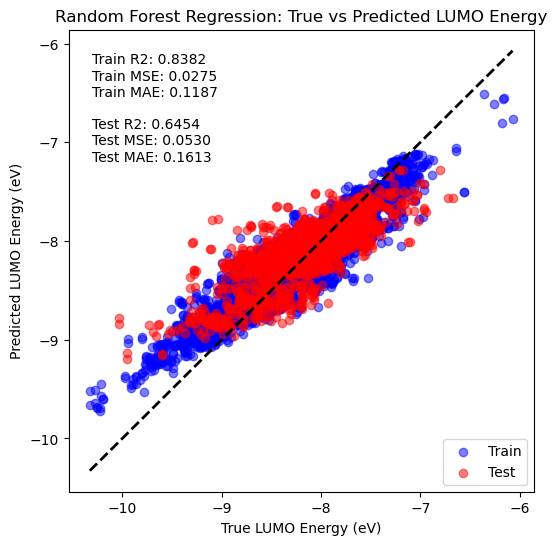

In [5]:
#regression plot including training and test data and label each performance metrics in the plot
plt.figure(figsize=(6,6))
plt.scatter(y_train, y_pred_train, color='blue', alpha=0.5, label='Train')
plt.scatter(y_test, y_pred_test, color='red', alpha=0.5, label='Test')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('True LUMO Energy (eV)')
plt.ylabel('Predicted LUMO Energy (eV)')
plt.title(f'Random Forest Regression: True vs Predicted LUMO Energy')
plt.text(0.05, 0.95, f'Train R2: {r2_train:.4f}\nTrain MSE: {mse_train:.4f}\nTrain MAE: {mae_train:.4f}\n\nTest R2: {r2_test:.4f}\nTest MSE: {mse_test:.4f}\nTest MAE: {mae_test:.4f}', transform=plt.gca().transAxes, verticalalignment='top')
plt.legend()
plt.show()

In [6]:
# optimize XGBoost regression hyperparameters using optuna
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
    }
    model = XGBRegressor(**param, random_state=42, n_jobs=4, objective='reg:squarederror')
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=1).mean()
    return score

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=20)
print(f"Best Params: {study_xgb.best_params}")

# Train and evaluate best model
best_xgb_optuna = XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1, objective='reg:squarederror')
best_xgb_optuna.fit(X_train, y_train)
y_pred_xgb = best_xgb_optuna.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"Optuna-tuned XGBoost - Test R2: {r2_xgb:.4f}")
joblib.dump(best_xgb_optuna, 'best_xgb_model_optuna.pkl')

[I 2026-03-04 10:49:53,211] A new study created in memory with name: no-name-aa96f968-d177-4197-a68f-dc20cc925d14
[I 2026-03-04 10:50:22,893] Trial 0 finished with value: -0.0599366919791642 and parameters: {'n_estimators': 80, 'max_depth': 3, 'learning_rate': 0.183012989168812, 'subsample': 0.9296961122188966, 'colsample_bytree': 0.8635621707547233, 'min_child_weight': 3}. Best is trial 0 with value: -0.0599366919791642.
[I 2026-03-04 10:50:54,546] Trial 1 finished with value: -0.05516375561660839 and parameters: {'n_estimators': 131, 'max_depth': 6, 'learning_rate': 0.1466429572109063, 'subsample': 0.8032707267263206, 'colsample_bytree': 0.7177389469332098, 'min_child_weight': 4}. Best is trial 1 with value: -0.05516375561660839.
[I 2026-03-04 10:51:21,341] Trial 2 finished with value: -0.056021655375797265 and parameters: {'n_estimators': 130, 'max_depth': 4, 'learning_rate': 0.2730357729651566, 'subsample': 0.9197891967358416, 'colsample_bytree': 0.6670403114853077, 'min_child_weig

Best Params: {'n_estimators': 291, 'max_depth': 4, 'learning_rate': 0.1131178915191017, 'subsample': 0.7462133522379487, 'colsample_bytree': 0.9094012893689222, 'min_child_weight': 4}
Optuna-tuned XGBoost - Test R2: 0.7232


['best_xgb_model_optuna.pkl']

In [7]:
#reload the model
loaded_xgb_optuna = joblib.load('best_xgb_model_optuna.pkl')
y_pred_train = loaded_xgb_optuna.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
print(f"Optuna-tuned XGB - Train R2: {r2_train:.4f} | MSE: {mse_train:.4f} | MAE: {mae_train:.4f}")
y_pred_test = loaded_xgb_optuna.predict(X_test)
r2_test = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
print(f"Optuna-tuned XGB - Test R2: {r2_test:.4f} | MSE: {mse_test:.4f} | MAE: {mae_test:.4f}")

Optuna-tuned XGB - Train R2: 0.8391 | MSE: 0.0273 | MAE: 0.1200
Optuna-tuned XGB - Test R2: 0.7232 | MSE: 0.0414 | MAE: 0.1452


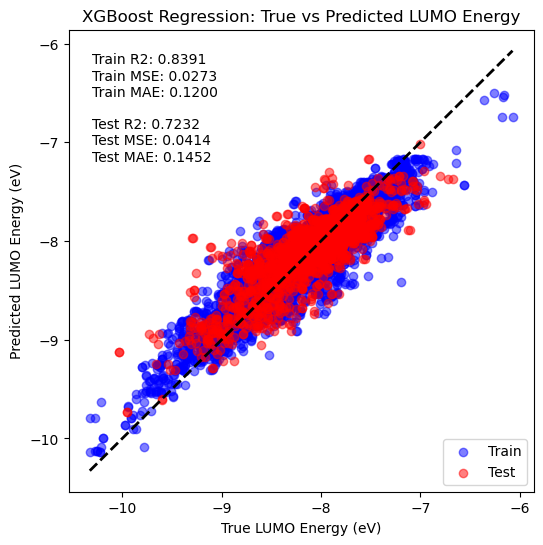

In [8]:
#regression plot including training and test data and label each performance metrics in the plot
plt.figure(figsize=(6,6))
plt.scatter(y_train, y_pred_train, color='blue', alpha=0.5, label='Train')
plt.scatter(y_test, y_pred_test, color='red', alpha=0.5, label='Test')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('True LUMO Energy (eV)')
plt.ylabel('Predicted LUMO Energy (eV)')
plt.title(f'XGBoost Regression: True vs Predicted LUMO Energy')
plt.text(0.05, 0.95, f'Train R2: {r2_train:.4f}\nTrain MSE: {mse_train:.4f}\nTrain MAE: {mae_train:.4f}\n\nTest R2: {r2_test:.4f}\nTest MSE: {mse_test:.4f}\nTest MAE: {mae_test:.4f}', transform=plt.gca().transAxes, verticalalignment='top')
plt.legend()
plt.show()

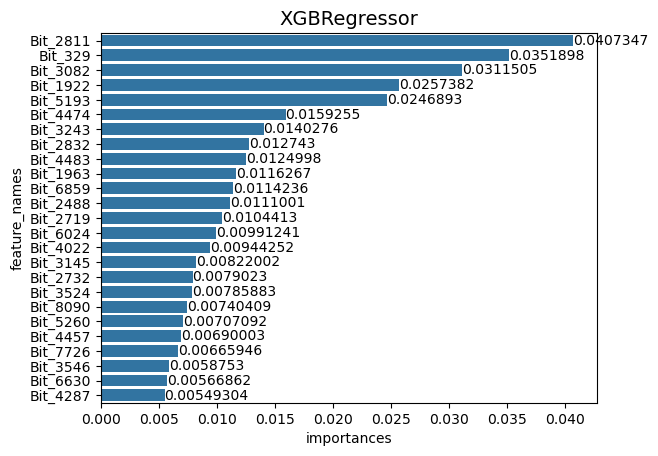

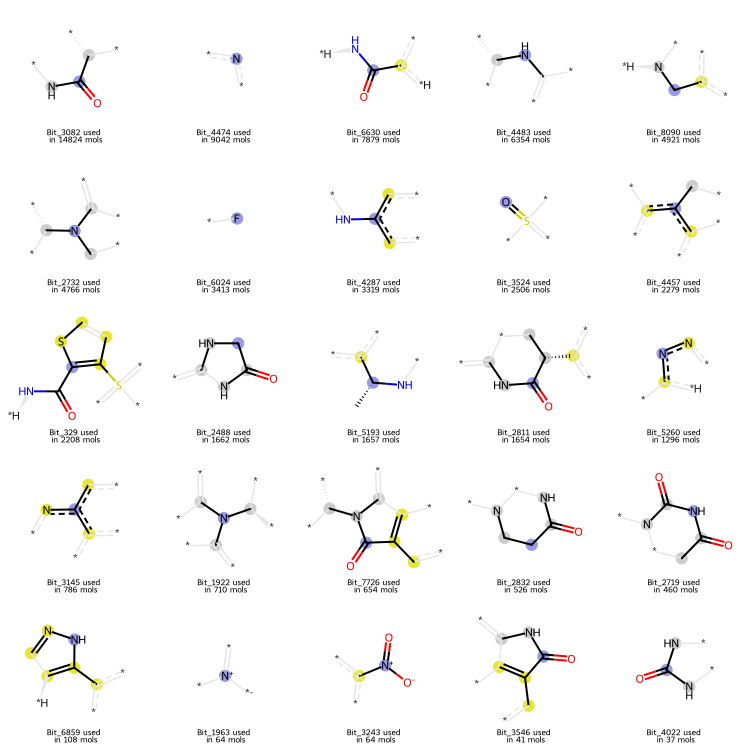

In [17]:
def plot_top_features(model, unique_bits, top_num=25):    
    try:
        importances_df = pd.DataFrame({"feature_names" : model.feature_names_in_, 
                                    "importances" : model.feature_importances_})
    except:
        importances_df = pd.DataFrame({"feature_names" : model.feature_names_in_, 
                                    "importances" : model.coef_[0]})
    importances_df = importances_df.sort_values(by='importances', ascending=False).head(top_num)
    g = sns.barplot(y=importances_df["feature_names"], 
                    x=importances_df["importances"])
    g.set_title(model.__class__.__name__, fontsize=14)
    for value in g.containers:
        g.bar_label(value)
    plt.show()
    plt.close()
    #
    top_bits = [int(i.split('_')[-1]) for i in importances_df["feature_names"].tolist()]
    found_bits = [item for item in unique_bits if item[1] in top_bits]
    display(Draw.DrawMorganBits(found_bits, molsPerRow=5, legends=[f'Bit_{str(t[1])} used \n in {str(bit_usage_counts[t[1]])} mols' for t in found_bits], subImgSize=(150,150)))

plot_top_features(loaded_xgb_optuna, unique_bits)

In [ ]:
gc.collect()

0

In [ ]:
with open('objs.pkl', 'wb') as f: 
    pickle.dump([loaded_svm_optuna, X_test, y_test, unique_bits], f)

In [2]:
with open('objs.pkl', 'rb') as f:
    loaded_svm_optuna, X_test, y_test, unique_bits = pickle.load(f)

In [3]:
# 1. Calculate Permutation Importance (this uses the test set)
print("Calculating permutation importance (this may take a moment)...")
r = permutation_importance(loaded_svm_optuna, X_test, y_test,
                           n_repeats=10,
                           random_state=42,
                           n_jobs=4)

# 2. Create a DataFrame for plotting
importances_df = pd.DataFrame({
    "feature_names": X_test.columns,
    "importances": r.importances_mean
})

# 3. Sort and select top features
top_num = 25
importances_df = importances_df.sort_values(by='importances', ascending=False).head(top_num)

# 4. Plot
plt.figure(figsize=(10, 6))
g = sns.barplot(y=importances_df["feature_names"], x=importances_df["importances"])
g.set_title("SVM (RBF Kernel) - Permutation Feature Importance", fontsize=14)
g.set_xlabel("Mean Decrease in Score")
plt.show()

# 5. Visualize the Molecular Bits (reusing your existing logic)
try:
    # Extract bit IDs from feature names (assuming format like 'Bit_123')
    top_bits = [int(i.split('_')[-1]) for i in importances_df["feature_names"].tolist()]
    
    # Find the matching bits in your unique_bits list
    found_bits = [item for item in unique_bits if item[1] in top_bits]
    
    display(Draw.DrawMorganBits(
        found_bits, 
        molsPerRow=5, 
        legends=[f'Bit_{str(t[1])}\nMatch' for t in found_bits], 
        subImgSize=(150,150)
    ))
except Exception as e:
    print(f"Could not visualize bits: {e}")

Calculating permutation importance (this may take a moment)...


KeyboardInterrupt: 